# Generalized E3SMLE and CESM-SMYLE Global Skill Maps

This notebook is adapted from `YeagerEA_GMD2022_revision1/f01_fB01_fB03.ipynb` and `YeagerEA_GMD2022_revision1/f02_fB02_fB04.ipynb`. It preserves their lead-time seasonal ACC methodology and map-analysis structure while refactoring data access for the E3SM and CESM-SMYLE comparison and generalizing the workflow across fields.

This notebook computes and plots seasonal skill for `TREFHT`, `PRECT`, or `PSL` using the same workflow.

Change only one line in the configuration cell below:

```python
# field = "TREFHT"  # surface air temperature
# field = "PRECT" # precipitation
# field = "PSL"   # sea-level pressure
```

Variable-specific observation product, observation variable name, unit conversion, labels, and cache filenames are handled through `VAR_CONFIG`.


In [6]:
%load_ext autoreload
%autoreload 2
import os
from pathlib import Path
import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
#from esp_lab import data_access_smyle.py as data_access
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid

# Default figure output directory for this HPC environment.
FIGURE_OUTDIR = Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag")
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)


def figure_filename(*parts, ext="png"):
    """Build consistent, readable lowercase snake_case figure filenames."""
    import re

    clean_parts = ["fig"]
    for part in parts:
        if part is None:
            continue
        text = str(part).strip()
        if not text:
            continue
        text = re.sub(r"[^A-Za-z0-9]+", "_", text).strip("_").lower()
        if text:
            clean_parts.append(text)

    suffix = ext.lstrip(".").lower()
    return "_".join(clean_parts) + f".{suffix}"


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import dask
from dask.distributed import (
    wait,
    get_client
)
dask.__version__

'2026.3.0'

## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [8]:
def get_ClusterClient(cluster_type='local', workers=4):
    """
    Create a Dask Cluster and Client based on the machine environment.
    cluster_type options: 'local', 'casper_pbs', 'slurm'
    """
    import dask
    from dask.distributed import Client
    
    # Optional global dask config
    dask.config.set({'array.slicing.split_large_chunks': True})

    if cluster_type == 'casper_pbs':
        # Specific to NCAR's Casper machine
        from dask_jobqueue import PBSCluster
        cluster = PBSCluster(
            cores=1,
            memory='20GB',
            processes=1,
            queue='casper',
            resource_spec='select=1:ncpus=1:mem=20GB',
            project='NCGD0011',
            walltime='02:00:00',
            interface='ib0'
        )
        dask.config.set({
            'distributed.dashboard.link':
            'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
        })
        client = Client(cluster)
        cluster.scale(30)
        
    elif cluster_type == 'slurm':
        from dask_jobqueue import SLURMCluster
        cluster = SLURMCluster(
            cores=4,
            processes=1,
            memory="16GB",
            walltime="02:00:00"
            # queue="compute", 
            # project="my_project" 
        )
        client = Client(cluster)
        cluster.scale(workers)
        
    elif cluster_type == 'local':
        from dask.distributed import LocalCluster
        cluster = LocalCluster(n_workers=workers)
        client = Client(cluster)
        
    else:
        raise ValueError(f"Unknown cluster_type: {cluster_type}")

    return cluster, client

# Set this to 'casper_pbs' when on NCAR Casper, or 'local' on your PC
machine_env = os.environ.get('CLUSTER_TYPE', 'local') 

try:
    client = get_client()
    print(client)
except ValueError:
    print("No active client")
try:
    client.close()
    cluster.close()
except:
    pass

cluster, client = get_ClusterClient(cluster_type=machine_env, workers=30)

<Client: 'tcp://127.0.0.1:45409' processes=30 threads=270, memory=502.97 GiB>


In [9]:
cluster

LocalCluster(e90e6bbb, 'tcp://127.0.0.1:42825', workers=30, threads=270, memory=502.97 GiB)

### Read in EAM monthly data; Convert to Seasonal averages (DJF, MAM, JJA, SON)
- Chosen field is returned as a dask array with leading dimensions of Y (initialization year), M (ensemble member), and L (lead season). For example, for November starts, L=1 corresponds to first DJF season.
- "time" which gives prediction verification time (centered time for a given season) is also dimensioned with (Y,L)

In [10]:
%%time
# -----------------------------------------------------------------------------
# Variable-driven setup
# -----------------------------------------------------------------------------
# Change this one line to switch diagnostics:
#   field = "TREFHT"  -> ERA5 tas, model/obs K -> degC
#   field = "PRECT"   -> GPCP PRECT, model m/s -> mm/day
#   field = "PSL"     -> ERA5 psl, model/obs Pa -> hPa
#field = "PRECT"
#field = "TREFHT"
field = "PSL"

def convert_kelvin_to_celsius(da):
    """Convert K to degC while preserving lazy evaluation."""
    da = da - 273.15
    da.attrs["units"] = r"$^\circ$C"
    return da


def convert_precip_mps_to_mmday(da):
    """Convert precipitation from m/s to mm/day while preserving lazy evaluation."""
    da = da * (1000.0 * 86400.0)
    da.attrs["units"] = "mm/day"
    return da


def convert_pa_to_hpa(da):
    """Convert pressure from Pa to hPa while preserving lazy evaluation."""
    da = da * 1.0e-2
    da.attrs["units"] = "hPa"
    return da


def no_unit_conversion(da, units=None):
    """Return a lazy copy and optionally standardize the unit attribute."""
    da = da * 1.0
    if units is not None:
        da.attrs["units"] = units
    return da


VAR_CONFIG = {
    "TREFHT": {
        "long_name": "2-m air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "tas",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_kelvin_to_celsius,
        "smyle_convert": convert_kelvin_to_celsius,
        "obs_convert": convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
    },
    "PRECT": {
        "long_name": "precipitation",
        "plot_name": "Precipitation",
        "obs_name": "GPCP_v2.3",
        "obs_var": "PRECT",
        "obs_ys": "1979",
        "obs_ye": "2017",
        "model_convert": convert_precip_mps_to_mmday,
        "smyle_convert": convert_precip_mps_to_mmday,
        # GPCP PRECT from this archive is already mm/day.
        "obs_convert": lambda da: no_unit_conversion(da, units="mm/day"),
        "units": "mm/day",
    },
    "PSL": {
        "long_name": "sea-level pressure",
        "plot_name": "Sea-level pressure",
        "obs_name": "ERA5",
        "obs_var": "psl",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": convert_pa_to_hpa,
        "smyle_convert": convert_pa_to_hpa,
        "obs_convert": convert_pa_to_hpa,
        "units": "hPa",
    },
}

if field not in VAR_CONFIG:
    raise ValueError(f"Unsupported field={field!r}. Available fields: {list(VAR_CONFIG)}")

cfg = VAR_CONFIG[field]
print(f"Selected field: {field} ({cfg['long_name']})")
print(f"Observation product: {cfg['obs_name']} variable={cfg['obs_var']}")

# Prefer the newer project path, but keep the older location used by the PSL notebook as a fallback.
data_dir_candidates = [
    "/global/cfs/cdirs/e3sm/S2S2D/post_process",
    "/global/cfs/cdirs/e3smdata/simulations/S2S2D/post_process",
]
data_dir = next((p for p in data_dir_candidates if os.path.exists(p)), data_dir_candidates[0])
print(f"Using post-processed data directory: {data_dir}")

case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"

case_nens = 10
case_nlead = 24
engine = "netcdf4"

years = 1980
yeare = 2018
yexcl = None

# Shared climatology window for drift removal, skill calculation, and checks.
climy0 = 1980
climy1 = 2010
init_months = [5, 11]

lead_years = [y for y in np.arange(years, yeare + 1) if y != yexcl]
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"
grid = "180x360_aave"
freq = "monthly"
ts_split = "2yr"

require_all_members = True
verify_field_name = True
verify_coverage = True
debug = True 

e3smle_by_month = {}

# Optional: safer open-time chunking.
chunks_open = {} # {"L": 24} can be used if needed.

mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

for init_month in init_months:
    init_tags = data_access.build_init_tags(lead_years, init_month)

    e3smle = data_access.get_monthly_data(
        data_dir=data_dir,
        case_prefix=case_prefix,
        members=members,
        init_tags=init_tags,
        field=field,
        nlead=case_nlead,
        chunks=chunks_open,
        realm=realm,
        grid=grid,
        freq=freq,
        ts_split=ts_split,
        require_all_members=require_all_members,
        verify_field_name=verify_field_name,
        verify_coverage=verify_coverage,
        engine=engine,
    )

    print(f"init_month={init_month}, size={e3smle.nbytes / 1e9:.2f} GB")

    # Apply final chunking after combine.
    e3smle = e3smle.chunk(mchunk)

    if debug:
        print(e3smle)
        print(e3smle.dims)
        print(e3smle.Y.values)
        print(e3smle.L.values[:5], e3smle.L.values[-5:])
        print(e3smle.time.isel(Y=0, L=slice(0, 3)).values)

    e3smle_by_month[init_month] = e3smle

e3smle05 = e3smle_by_month.get(5)
e3smle11 = e3smle_by_month.get(11)


Selected field: PSL (sea-level pressure)
Observation product: ERA5 variable=psl
Using post-processed data directory: /global/cfs/cdirs/e3sm/S2S2D/post_process
init_month=5, size=2.43 GB
<xarray.Dataset> Size: 2GB
Dimensions:  (Y: 39, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * Y        (Y) <U10 2kB '1980050100' '1981050100' ... '2018050100'
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    time     (Y, L) object 7kB dask.array<chunksize=(3, 24), meta=np.ndarray>
    PSL      (Y, L, M, lat, lon) float32 2GB dask.array<chunksize=(3, 24, 2, 90, 180), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'Y': 39, 'L': 24, 'M': 10, 'lat': 180, 'lon': 360})
['1980050100' '1981050100' '1982050100' '198305

### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [11]:
%%time
outdir = "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE"
os.makedirs(outdir, exist_ok=True)

debug = False #True
force_rewrite = True
encoding = {
    field: {
        "chunksizes": (1, 8, 1, 90, 180),
        "zlib": True,
        "complevel": 1
    }
}
e3smle_seas_by_month = {}

for init_month in init_months:

    outname = f"E3SMLE{init_month:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
    outfile = os.path.join(outdir, outname)

    if os.path.exists(outfile) and not force_rewrite:
        e3smle_seas = xr.open_dataset(outfile, chunks=mchunk)
    else:
        if os.path.exists(outfile):
            os.remove(outfile)

        e3smle = e3smle_by_month[init_month]

        # 1. seasonal aggregation (lazy)
        e3smle_seas = cal.mon_to_seas_dask(e3smle)

        # 2. rechunk after rolling
        e3smle_seas = e3smle_seas.chunk(mchunk)

        # 3. persist (optional but OK since reused)
        e3smle_seas = e3smle_seas.persist()

        # 4. write with encoding
        e3smle_seas.to_netcdf(outfile, encoding=encoding)

    e3smle_seas_by_month[init_month] = e3smle_seas

    # debug
    if debug:
        print(f"\ninit_month={init_month}")
        print(e3smle_seas)
        print(e3smle_seas.dims)
        print(e3smle_seas.Y.values)
        print(e3smle_seas.L.values[:5], e3smle_seas.L.values[-5:])
        print(e3smle_seas.time.isel(Y=0, L=slice(0, 3)).values)

# convenient access
e3smle05_seas = e3smle_seas_by_month.get(5)
e3smle11_seas = e3smle_seas_by_month.get(11)

if debug:
    print("available seasonal init months:", sorted(e3smle_seas_by_month))

CPU times: user 13.7 s, sys: 7.38 s, total: 21 s
Wall time: 48.4 s


### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [12]:
%%time
# Regrid all E3SMLE hindcast data to the common analysis grid.
target_dlat = 1.0
target_dlon = 1.0

destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)
regrid_method = "conservative"
regrid_periodic = True

# Ensure clean chunking before regrid.
e3smle_seas_by_month = {
    init_month: ds.chunk(mchunk)
    for init_month, ds in e3smle_seas_by_month.items()
}

# Build one regridder from the first available initialization month.
_ref_month = init_months[0]
regridder = regrid.make_regridder(
    e3smle_seas_by_month[_ref_month],
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

# Regrid, rechunk, and apply variable-specific unit conversion by init month.
e3smle_da_by_month = {}
for init_month in init_months:
    da = regridder(e3smle_seas_by_month[init_month][field]).chunk(mchunk)
    da = cfg["model_convert"](da)
    e3smle_da_by_month[init_month] = da

    print(f"init_month={init_month}")
    print(da.shape)
    print(da.dims)
    print(da.Y.values)
    print(da.L.values[:5], da.L.values[-5:])
    print("units:", da.attrs.get("units"))

# Backward-compatible convenience variables for exploratory cells.
e3smle05_da = e3smle_da_by_month.get(5)
e3smle11_da = e3smle_da_by_month.get(11)


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)


init_month=5
(39, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980050100' '1981050100' '1982050100' '1983050100' '1984050100'
 '1985050100' '1986050100' '1987050100' '1988050100' '1989050100'
 '1990050100' '1991050100' '1992050100' '1993050100' '1994050100'
 '1995050100' '1996050100' '1997050100' '1998050100' '1999050100'
 '2000050100' '2001050100' '2002050100' '2003050100' '2004050100'
 '2005050100' '2006050100' '2007050100' '2008050100' '2009050100'
 '2010050100' '2011050100' '2012050100' '2013050100' '2014050100'
 '2015050100' '2016050100' '2017050100' '2018050100']
[ 3  6  9 12 15] [12 15 18 21 24]
units: hPa
init_month=11
(39, 8, 10, 181, 360)
('Y', 'L', 'M', 'lat', 'lon')
['1980110100' '1981110100' '1982110100' '1983110100' '1984110100'
 '1985110100' '1986110100' '1987110100' '1988110100' '1989110100'
 '1990110100' '1991110100' '1992110100' '1993110100' '1994110100'
 '1995110100' '1996110100' '1997110100' '1998110100' '1999110100'
 '2000110100' '2001110100' '2002110100' '200

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (90, 180).
  result_var = func(*data_vars)


### Load CESM-SMYLE benchmark data
- Benchmark files are pre-generated once by `workflows/preprocess_cesm_smyle_benchmark.py` and stored at `/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/`.
- Each file contains seasonal means on the native f09_g17 grid with dimensions `(Y, L, M, lat, lon)`.
- The benchmark is regridded here to the same analysis grid as E3SM before skill is computed.


In [13]:
%%time
# Load and regrid CESM-SMYLE benchmark data to the same analysis grid as E3SM.
from esp_lab import data_access_cesm_smyle as smyle_access

SMYLE_BENCHMARK_DIR = "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE"
smyle_nens = 20
smyle_nlead = 24
mchunk_smyle = {"Y": 3, "L": -1, "M": 2, "lat": 96, "lon": 144}

smyle_seas_by_month = {}
for init_month in init_months:
    ds = smyle_access.load_benchmark(
        field=field,
        init_month=init_month,
        benchmark_dir=SMYLE_BENCHMARK_DIR,
        nens=smyle_nens,
        nlead=smyle_nlead,
        freq="seas",
        chunks=mchunk_smyle,
    )
    smyle_seas_by_month[init_month] = ds.chunk(mchunk_smyle)
    print(f"CESM-SMYLE init_month={init_month}: {ds.sizes}")

regridder_smyle = regrid.make_regridder(
    smyle_seas_by_month[init_months[0]],
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

smyle_da_by_month = {}
for init_month in init_months:
    da = regridder_smyle(smyle_seas_by_month[init_month][field]).chunk(mchunk)
    da = cfg["smyle_convert"](da)
    smyle_da_by_month[init_month] = da

    print(f"CESM-SMYLE regridded init_month={init_month}: {da.sizes}")
    print("units:", da.attrs.get("units"))

smyle05_seas = smyle_seas_by_month.get(5)
smyle11_seas = smyle_seas_by_month.get(11)
smyle05_da = smyle_da_by_month.get(5)
smyle11_da = smyle_da_by_month.get(11)


CESM-SMYLE init_month=5: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE init_month=11: Frozen({'Y': 38, 'L': 8, 'M': 20, 'lat': 192, 'lon': 288})
CESM-SMYLE regridded init_month=5: Frozen({'Y': 39, 'L': 8, 'M': 20, 'lat': 181, 'lon': 360})
units: hPa
CESM-SMYLE regridded init_month=11: Frozen({'Y': 38, 'L': 8, 'M': 20, 'lat': 181, 'lon': 360})
units: hPa
CPU times: user 4.1 s, sys: 920 ms, total: 5.02 s
Wall time: 4.5 s


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)
/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/xarray/computation/apply_ufunc.py:312: PerformanceWarning: Regridding is increasing the number of chunks by a factor of 6.0, you might want to specify sizes in `output_chunks` in the regridder call. Default behaviour is to preserve the chunk sizes from the input (96, 144).
  result_var = func(*data_vars)


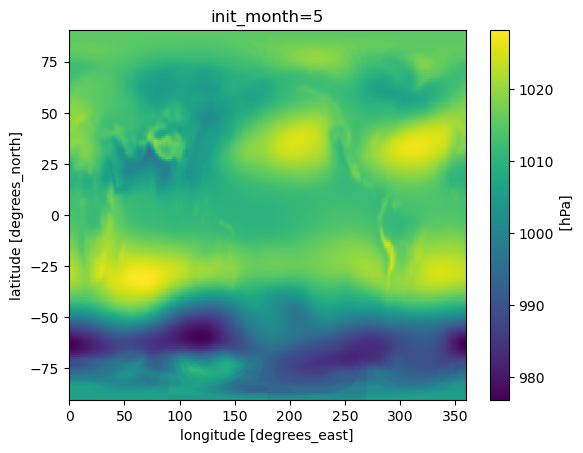

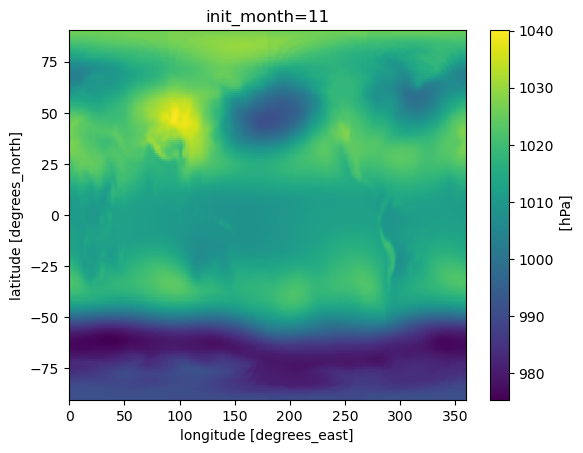

In [14]:
for init_month, da in e3smle_da_by_month.items():
    da.isel(Y=0, L=0, M=0).plot()
    plt.title(f"init_month={init_month}")
    plt.show()

### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

In [15]:
%%time
# Load observations using the selected field configuration.
obs_dir = "/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series"
obs_name = cfg["obs_name"]
obs_var = cfg["obs_var"]
obs_map = {field: obs_var}
obs_ys = cfg["obs_ys"]
obs_ye = cfg["obs_ye"]
verbose = True

obs_chunks = {
    "time": 24,
    "lat": 90,
    "lon": 180,
}

obs_monthly = obs_access.get_monthly_data(
    obs_dir=obs_dir,
    field=field,
    field_map=obs_map,
    product=obs_name,
    start_year=obs_ys,
    end_year=obs_ye,
    chunks=obs_chunks,
    verbose=verbose,
)

# Compute OBS seasonal averages.
obs_seas = obs_access.mon_to_seas_obs(
    obs_monthly,
    var=obs_var,
    field_map=obs_map,
)

# Rechunk after rolling.
obs_seas = obs_seas.chunk(obs_chunks)

# Build regridder from Dataset, not DataArray.
regridder_obs = regrid.make_regridder(
    obs_monthly,
    destgrid,
    method=regrid_method,
    periodic=regrid_periodic,
)

# Regrid seasonal DataArray.
try:
    obs_seas_rg = regridder_obs(
        obs_seas,
        output_chunks=obs_chunks,
    )
except TypeError:
    obs_seas_rg = regridder_obs(obs_seas)

# Rechunk after regrid and apply variable-specific unit conversion.
obs_seas_rg = obs_seas_rg.chunk(obs_chunks)
print(obs_seas_rg)

obs_seas_rg = cfg["obs_convert"](obs_seas_rg)
print(obs_seas_rg)

# Backward-compatible aliases for older exploratory cells.
if cfg["obs_name"] == "ERA5":
    obs_era5_seas_rg = obs_seas_rg
if field == "PRECT":
    obs_gpcp_seas_rg = obs_seas_rg


[OBS] Mapping field 'PSL' -> 'psl'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/ERA5/psl_197901_201912.nc
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<astype, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Attributes:
    regrid_method:  conservative
<xarray.DataArray (time: 490, lat: 181, lon: 360)> Size: 128MB
dask.array<mul, shape=(490, 181, 360), dtype=float32, chunksize=(24, 90, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.

/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.14/site-packages/distributed/client.py:3398: UserWarning: Sending large graph of size 38.54 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


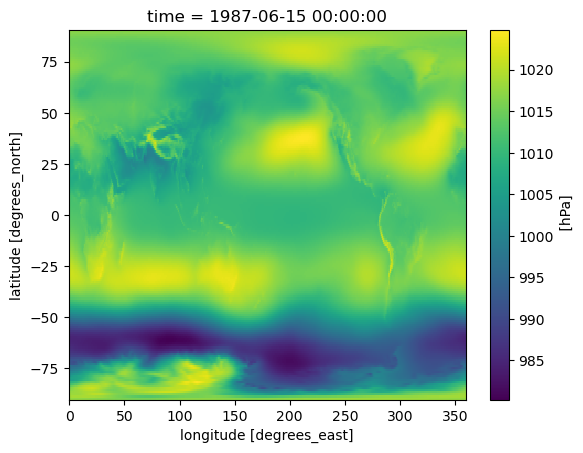

In [16]:
obs_seas_rg.isel(time=100).plot()

# Skill Analysis

In [17]:
%%time
time_by_month = {
    init_month: e3smle_seas_by_month[init_month].time.load()
    for init_month in init_months
}

# Backward-compatible convenience variables for exploratory cells.
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)

CPU times: user 26.2 ms, sys: 0 ns, total: 26.2 ms
Wall time: 37.9 ms


In [18]:
%%time
# Compute de-drifted anomalies from specified climatology

anom_by_month = {}
clim_by_month = {}

for init_month in init_months:
    anom_by_month[init_month], clim_by_month[init_month] = stats.remove_drift(
        e3smle_da_by_month[init_month],
        time_by_month[init_month],
        climy0,
        climy1,
    )

# Backward-compatible convenience variables for exploratory cells.
e3smle05_anom = anom_by_month.get(5)
e3smle11_anom = anom_by_month.get(11)
e3smle05_clim = clim_by_month.get(5)
e3smle11_clim = clim_by_month.get(11)

CPU times: user 23.1 ms, sys: 0 ns, total: 23.1 ms
Wall time: 21.8 ms


In [19]:
%%time
# Compute CESM-SMYLE benchmark de-drifted anomalies from the same climatology window.
smyle_time_by_month = {
    init_month: smyle_seas_by_month[init_month].time.load()
    for init_month in init_months
}

smyle_anom_by_month = {}
smyle_clim_by_month = {}

for init_month in init_months:
    smyle_anom_by_month[init_month], smyle_clim_by_month[init_month] = stats.remove_drift(
        smyle_da_by_month[init_month],
        smyle_time_by_month[init_month],
        climy0,
        climy1,
    )

smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)
smyle05_anom = smyle_anom_by_month.get(5)
smyle11_anom = smyle_anom_by_month.get(11)
smyle05_clim = smyle_clim_by_month.get(5)
smyle11_clim = smyle_clim_by_month.get(11)


CPU times: user 109 ms, sys: 20.5 ms, total: 129 ms
Wall time: 178 ms


In [20]:
def check_remove_drift(da, da_time, anom, clim, climy0, climy1, name="case"):
    d1 = cftime.DatetimeNoLeap(climy0, 1, 1, 0, 0, 0)
    d2 = cftime.DatetimeNoLeap(climy1, 12, 31, 23, 59, 59)

    masked = da.where((da_time >= d1) & (da_time <= d2))
    clim_manual = masked.mean("M").mean("Y")
    anom_manual = da - clim_manual
    masked_anom = anom.where((da_time >= d1) & (da_time <= d2))

    print(f"=== {name} ===")
    print("raw dims :", da.dims, da.shape)
    print("anom dims:", anom.dims, anom.shape)
    print("clim dims:", clim.dims, clim.shape)

    xr.testing.assert_allclose(clim, clim_manual)
    xr.testing.assert_allclose(anom, anom_manual)
    print("manual reconstruction: PASS")

    resid = masked_anom.mean(("Y", "M"))
    print("max abs masked anomaly mean:", float(abs(resid).max(skipna=True)))

    nvalid = masked.notnull().sum(("Y", "M"))
    print("min valid samples per (L,lat,lon):", int(nvalid.min(skipna=True)))
    print("max valid samples per (L,lat,lon):", int(nvalid.max(skipna=True)))

    print("missing clim cells by lead:")
    print(clim.isnull().sum(("lat", "lon")))

for init_month in init_months:
    check_remove_drift(
        e3smle_da_by_month[init_month],
        time_by_month[init_month],
        anom_by_month[init_month],
        clim_by_month[init_month],
        climy0,
        climy1,
        f"init_month={init_month}",
    )

=== init_month=5 ===
raw dims : ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
anom dims: ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
clim dims: ('L', 'lat', 'lon') (8, 181, 360)
manual reconstruction: PASS
max abs masked anomaly mean: 0.00020365396630950272
min valid samples per (L,lat,lon): 0
max valid samples per (L,lat,lon): 310
missing clim cells by lead:
<xarray.DataArray (L: 8)> Size: 64B
dask.array<sum-aggregate, shape=(8,), dtype=int64, chunksize=(8,), chunktype=numpy.ndarray>
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
Attributes:
    regrid_method:  conservative
    units:          hPa
=== init_month=11 ===
raw dims : ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
anom dims: ('Y', 'L', 'M', 'lat', 'lon') (39, 8, 10, 181, 360)
clim dims: ('L', 'lat', 'lon') (8, 181, 360)
manual reconstruction: PASS
max abs masked anomaly mean: 0.00019846949726343155
min valid samples per (L,lat,lon): 0
max valid samples per (L,lat,lon): 300
missing clim cell

In [21]:
%%time
# Compute and save skill data separately for each init month
outdir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

# False reuses existing skill NetCDF files; set True only for intentional regeneration.
force_compute = False
detrend = True

skill_chunk_model = {
    "Y": -1,
    "L": 8,
    "M": 2,
    "lat": 45,
    "lon": 90,
}

skill_chunk_obs = {
    "time": -1,
    "lat": 45,
    "lon": 90,
}

clim_start = cftime.DatetimeNoLeap(climy0, 1, 1)
clim_end = cftime.DatetimeNoLeap(climy1, 12, 31)

# anom_by_month and time_by_month are keyed by the actual init_month values above.

skill_by_month = {}

obs_skill = obs_seas_rg.chunk(skill_chunk_obs)

for init_month in init_months:
    if detrend:
        outname = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        outname = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    outfile = os.path.join(outdir, outname)

    if os.path.exists(outfile) and not force_compute:
        skill_ds = xr.open_dataset(outfile).load()
    else:
        if force_compute and os.path.exists(outfile):
            os.remove(outfile)

        model_anom = anom_by_month[init_month].chunk(skill_chunk_model)
        model_time = time_by_month[init_month]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            1,
            8,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = xr.Dataset({
            "corr": skill.corr,
            "pval": skill.pval,
            "rmse": skill.rmse,
            "msss": skill.msss,
            "rpc": skill.rpc,
            "sig_obs": skill.sig_obs,
            "sig_sig": skill.sig_sig,
            "sig_tot": skill.sig_tot,
            "s2t": skill.s2t,
        }).compute()

        skill_ds.to_netcdf(outfile)

    skill_by_month[init_month] = skill_ds

    print(outfile)
    print(skill_ds)

skill05_ds = skill_by_month.get(5)
skill11_ds = skill_by_month.get(11)

/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE/E3SMLE05_PSL_skill_clim_1980_2010_detrend.nc
<xarray.Dataset> Size: 38MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    corr     (L, lat, lon) float64 4MB 0.246 0.2443 0.2442 0.244 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.1423 0.145 0.1452 ... nan nan nan
    rmse     (L, lat, lon) float64 4MB 0.9875 0.9886 0.9887 ... nan nan nan
    msss     (L, lat, lon) float64 4MB 0.0248 0.02259 0.02244 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.6554 0.6523 0.6519 ... nan nan nan
    sig_obs  (L, lat, lon) float64 4MB 3.747 3.746 3.745 ... 4.521 4.522 4.523
    sig_sig  (L, lat, lon) float64 4MB 1.629 1.637 1.637 1.637 ... nan nan nan
    sig_tot  (L, lat, lon) float64 4MB 4.342 4.37 4.37 4.37 ...

In [22]:
%%time
# Compute and save CESM-SMYLE benchmark skill with the same observations/settings.
smyle_skill_outdir = SMYLE_BENCHMARK_DIR
os.makedirs(smyle_skill_outdir, exist_ok=True)

smyle_skill_by_month = {}
obs_skill = obs_skill.chunk(skill_chunk_obs)

for init_month in init_months:
    if detrend:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        outname = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    outfile = os.path.join(smyle_skill_outdir, outname)

    if os.path.exists(outfile) and not force_compute:
        skill_ds = xr.open_dataset(outfile).load()
    else:
        if force_compute and os.path.exists(outfile):
            os.remove(outfile)

        model_anom = smyle_anom_by_month[init_month].chunk(skill_chunk_model)
        model_time = smyle_time_by_month[init_month]

        skill = stats.compute_skill_seasonal(
            model_anom,
            model_time,
            obs_skill,
            clim_start,
            clim_end,
            1,
            8,
            resamp=0,
            detrend=detrend,
        )

        skill_ds = xr.Dataset({
            "corr": skill.corr,
            "pval": skill.pval,
            "rmse": skill.rmse,
            "msss": skill.msss,
            "rpc": skill.rpc,
            "sig_obs": skill.sig_obs,
            "sig_sig": skill.sig_sig,
            "sig_tot": skill.sig_tot,
            "s2t": skill.s2t,
        }).compute()

        skill_ds.to_netcdf(outfile)

    smyle_skill_by_month[init_month] = skill_ds
    print(outfile)
    print(skill_ds)

smyle05_skill_ds = smyle_skill_by_month.get(5)
smyle11_skill_ds = smyle_skill_by_month.get(11)

skill_delta_by_month = {
    init_month: skill_by_month[init_month].corr - smyle_skill_by_month[init_month].corr
    for init_month in init_months
}


/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/BSMYLE05_PSL_skill_clim_1980_2010_detrend.nc
<xarray.Dataset> Size: 38MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    corr     (L, lat, lon) float64 4MB 0.2895 0.2897 0.2898 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.07381 0.07365 0.07353 ... nan nan nan
    rmse     (L, lat, lon) float64 4MB 0.9573 0.9573 0.9572 ... nan nan nan
    msss     (L, lat, lon) float64 4MB 0.08354 0.08363 0.08369 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 1.028 1.028 1.028 1.029 ... nan nan nan
    sig_obs  (L, lat, lon) float64 4MB 3.747 3.746 3.745 ... 4.521 4.522 4.523
    sig_sig  (L, lat, lon) float64 4MB 1.021 1.021 1.022 1.022 ... nan nan nan
    sig_tot  (L, lat, lon) float64 4MB 3.625 3.625 3.625

### Final ACC Plot: BSMYLE vs E3SMLE
- Reads saved skill files for both BSMYLE/CESM-SMYLE and E3SMLE.
- Plots each initialization month as paired columns: CESM-SMYLE on the left, E3SMLE on the right.
- Adds light latitude-longitude gridlines with labels only on the outer plot edges.


=== Sanity check: data range ===
CESM-SMYLE init_month=5 corr min/max: -0.5616152550422828 0.8764891290389408
CESM-SMYLE init_month=11 corr min/max: -0.4650863063256262 0.9199433662013186
E3SMLE init_month=5 corr min/max: -0.6217274506202143 0.8453750400839839
E3SMLE init_month=11 corr min/max: -0.5571234871603229 0.9266888023841456
working on figure: fig_psl_leadtime_acc_e3smv3_s2dle_bsmyle_global_wt_detrend_wt_sigmask.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_leadtime_acc_e3smv3_s2dle_bsmyle_global_wt_detrend_wt_sigmask.png


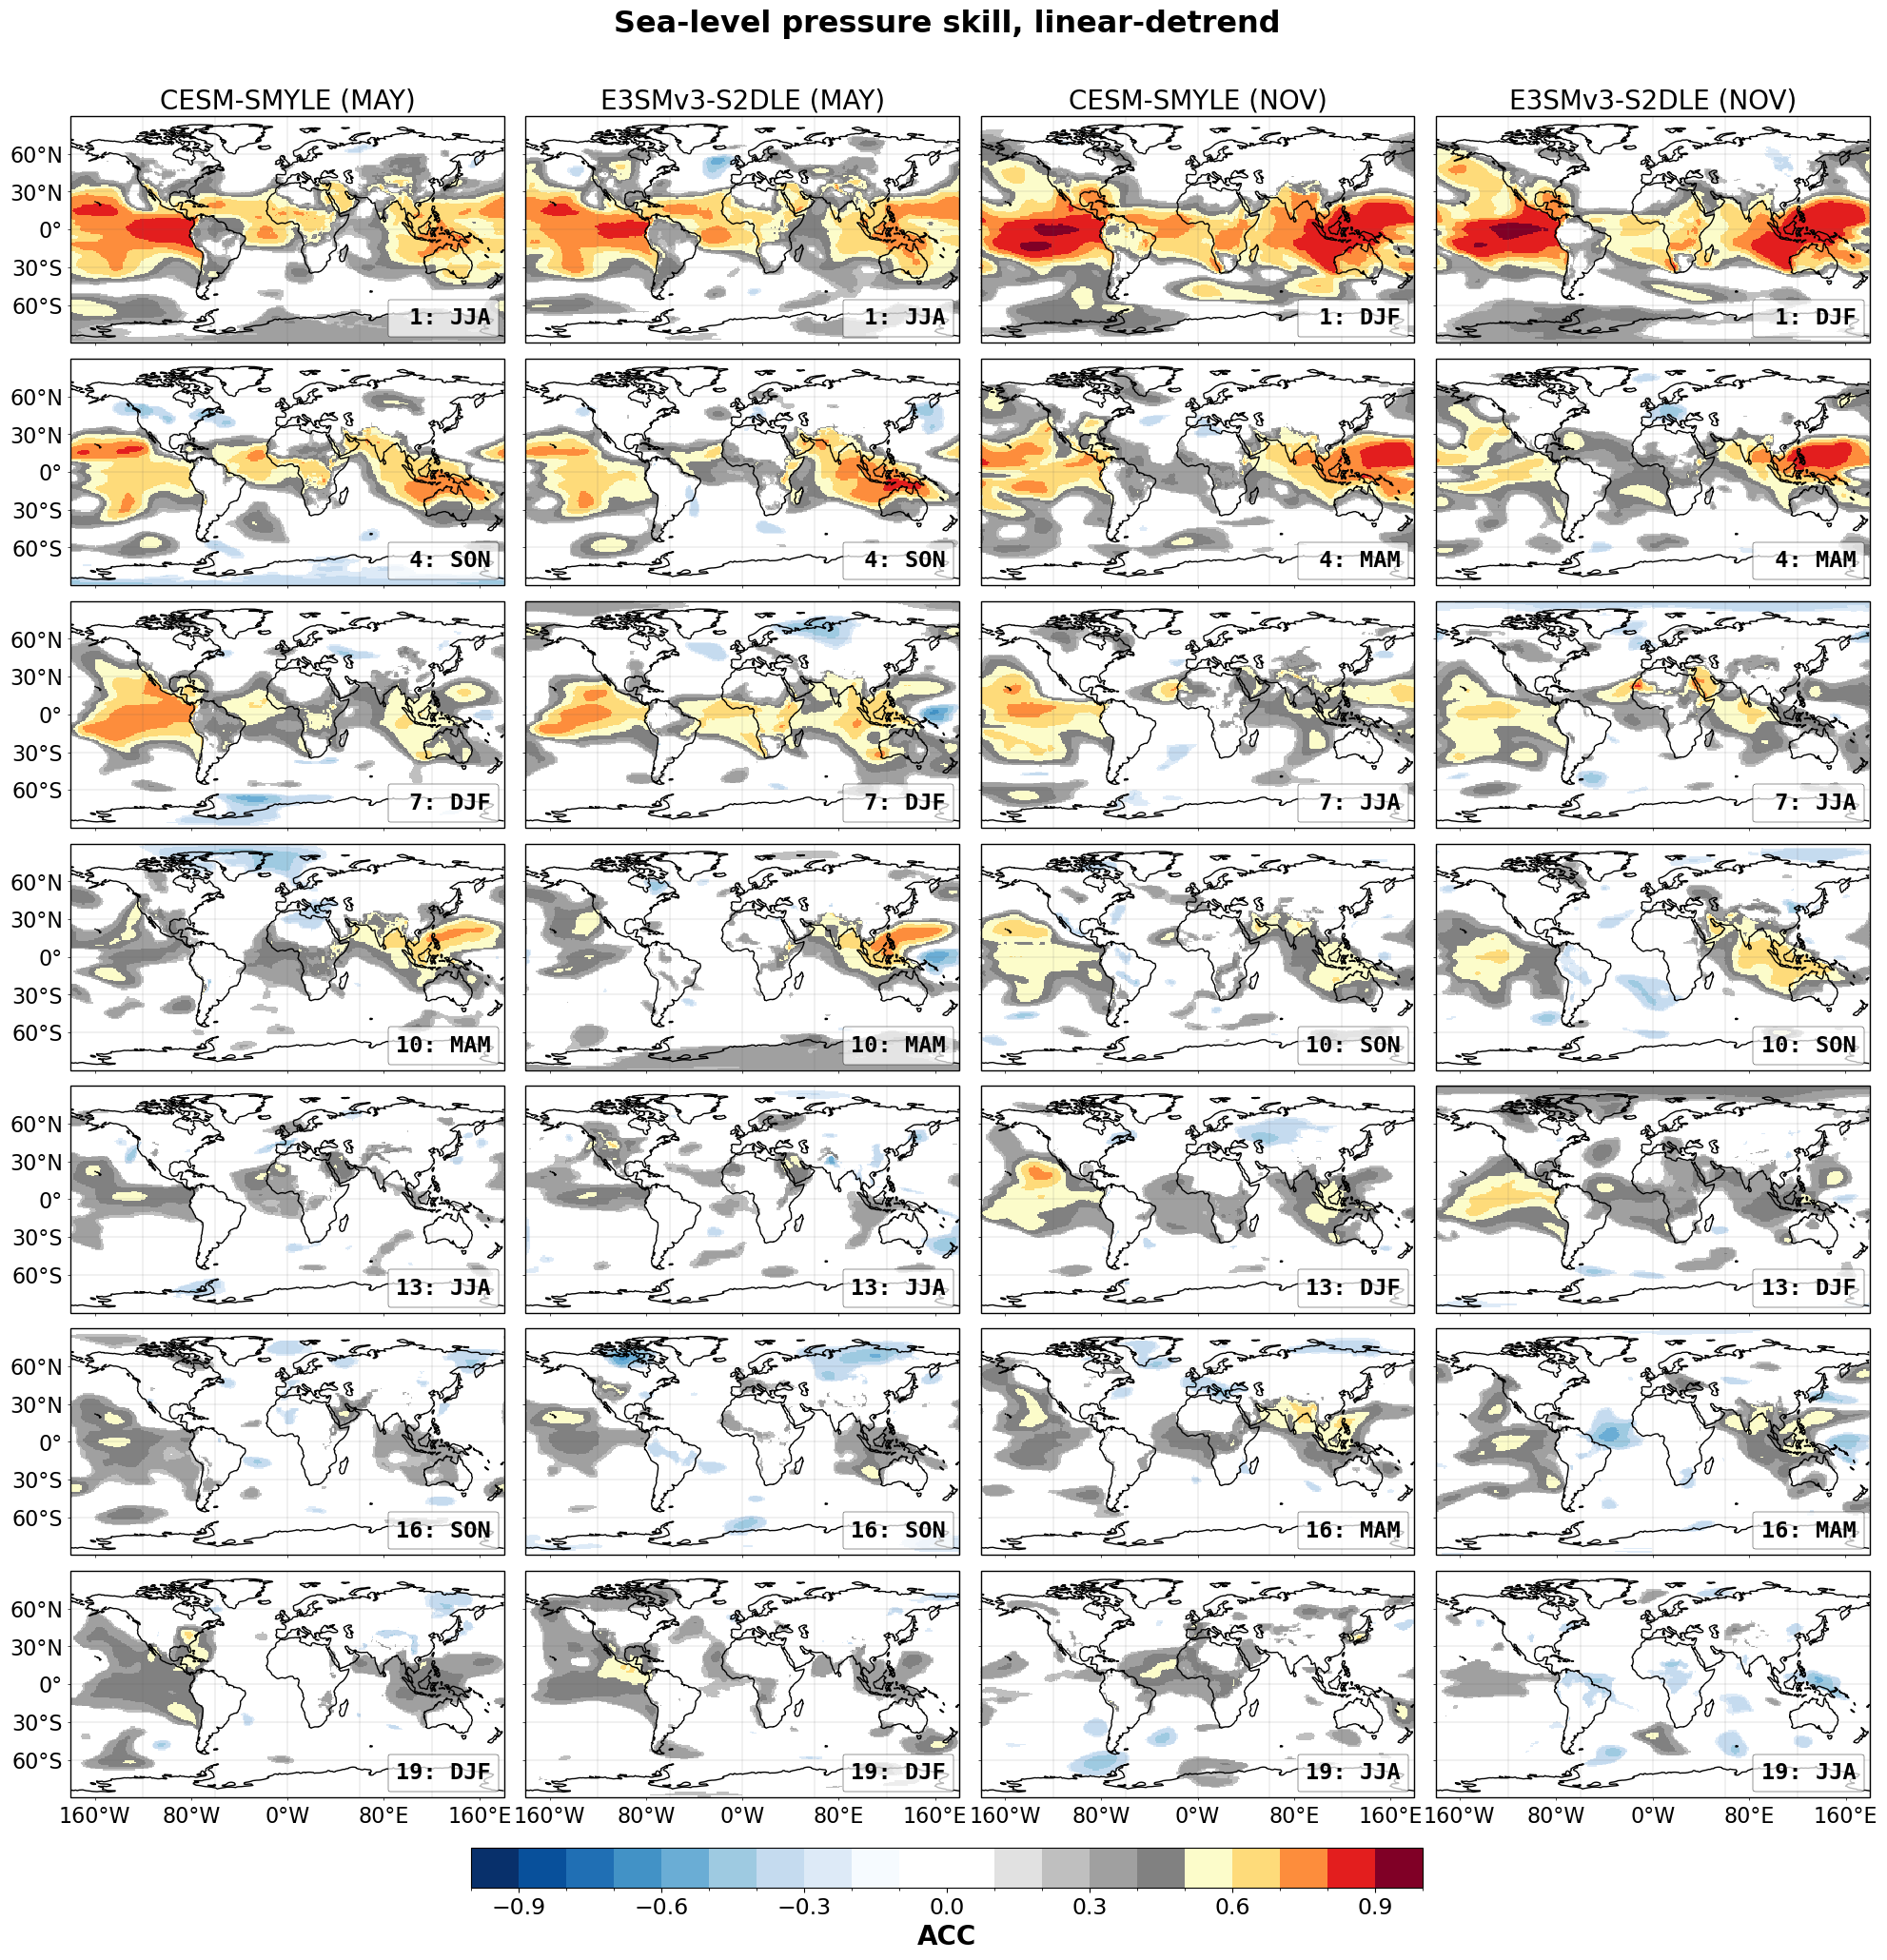

CPU times: user 15.5 s, sys: 3.53 s, total: 19 s
Wall time: 15.3 s


In [23]:
%%time
# Read saved BSMYLE/CESM-SMYLE and E3SMv3-S2DLE skill data and plot side by side.
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.offsetbox import AnchoredText

from esp_lab.utils import mapplot_utils as maps

# Standalone defaults make this cell safe to run after a kernel restart.
field = globals().get("field", "PSL")
init_months = globals().get("init_months", [5, 11])
climy0 = globals().get("climy0", 1980)
climy1 = globals().get("climy1", 2010)
detrend = globals().get("detrend", True)
plot_names = {
    "TREFHT": "Surface air temperature",
    "PRECT": "Precipitation",
    "PSL": "Sea-level pressure",
}
cfg = globals().get("cfg", {"plot_name": plot_names.get(field, field)})
FIGURE_OUTDIR = globals().get(
    "FIGURE_OUTDIR",
    Path("/global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag"),
)
FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

if "figure_filename" not in globals():
    def figure_filename(*parts, ext="png"):
        clean = ["fig"]
        for part in parts:
            token = re.sub(r"[^A-Za-z0-9]+", "_", str(part)).strip("_").lower()
            if token:
                clean.append(token)
        return "_".join(clean) + f".{ext.lstrip('.').lower()}"

# ---------------------------------------------------------------------------
# User-adjustable final-plot setup
# ---------------------------------------------------------------------------
e3smle_skill_dir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE'
smyle_skill_dir = '/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE'

metric = "ACC"
model_order = ["CESM-SMYLE", "E3SMLE"]
model_display_name = {
    "CESM-SMYLE": "CESM-SMYLE",
    "E3SMLE": "E3SMv3-S2DLE",
}
# Seasonal lead denotes the first monthly lead in each 3-month window:
# lead 1 = months 1-3, lead 4 = months 4-6, etc.
skill_leads = [1, 4, 7, 10, 13, 16, 19, 22]
map_plot_leads = skill_leads[:-1]
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}

sigon = True
siglvl = 0.1
mask_negacc = False

# Single font-size control for the full multi-panel figure.
fontz = 20
panel_title_size = fontz
lead_label_size = fontz * 0.85
lat_lon_label_size = fontz * 0.8
colorbar_label_size = fontz
colorbar_tick_size = fontz * 0.85
suptitle_size = fontz * 1.15
fweight = 'bold'

# Plot style/layout controls.
figfmt = "png"
fig_col_width = 5.0
fig_row_height = 3.0
projection = ccrs.PlateCarree()
suptitle_y = 0.995
tight_layout_rect = [0, 0.16, 1, 0.985]
bottom = 0.10
wspace = 0.05
save_bbox = "tight"

cmap = "blue2red_acc"
coff = 0.5
ci = 0.1
cmin = -1
cmax = 1

colorbar_axes = [0.25, 0.055, 0.5, 0.02]
colorbar_orientation = 'horizontal'
dpi = 300

lon_ticks = [-160, -80, 0, 80, 160]
lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 1.0
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"

lead_label_loc = "lower right"
lead_label_pad = 0.25
lead_label_borderpad = 0.35
lead_label_bbox = dict(facecolor=(1, 1, 1, 0.72), edgecolor='black', linewidth=0.3, boxstyle='round,pad=0.1')

skill_by_model = {
    "E3SMLE": {},
    "CESM-SMYLE": {},
}

for init_month in init_months:
    if detrend:
        e3smle_name = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
        smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}_detrend.nc"
    else:
        e3smle_name = f"E3SMLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"
        smyle_name = f"BSMYLE{init_month:02d}_{field}_skill_clim_{climy0}_{climy1}.nc"

    skill_by_model["E3SMLE"][init_month] = xr.open_dataset(
        os.path.join(e3smle_skill_dir, e3smle_name)
    ).load()
    skill_by_model["CESM-SMYLE"][init_month] = xr.open_dataset(
        os.path.join(smyle_skill_dir, smyle_name)
    ).load()

# Keep the old variable name available for exploratory cells below/above.
skill_by_month = skill_by_model["E3SMLE"]
smyle_skill_by_month = skill_by_model["CESM-SMYLE"]

def seasonal_label(init_month, lead):
    center_month = ((init_month + lead + 1 - 1) % 12) + 1
    return season_names[((center_month % 12) // 3)]


def lead_label(init_month, lead):
    return f"{lead:2d}: {seasonal_label(init_month, lead)}"


def add_lead_label(ax, text):
    label = AnchoredText(
        text,
        loc=lead_label_loc,
        prop=dict(size=lead_label_size, weight=fweight, family="monospace"),
        frameon=True,
        pad=lead_label_pad,
        borderpad=lead_label_borderpad,
    )
    label.patch.set(**lead_label_bbox)
    ax.add_artist(label)


def set_map_axis_linewidth(ax):
    for spine in ax.spines.values():
        spine.set_linewidth(map_axis_linewidth)
    if hasattr(ax, "outline_patch"):
        ax.outline_patch.set_linewidth(map_axis_linewidth)


def add_lat_lon_labels(ax, row, col, nrows, ncols):
    # Keep labels on the outer edges so the multi-panel plot stays readable.
    set_map_axis_linewidth(ax)
    ax.set_xticks(lon_ticks, crs=projection)
    ax.set_yticks(lat_ticks, crs=projection)
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(
        labelsize=lat_lon_label_size,
        length=lat_lon_tick_length,
        width=lat_lon_tick_width,
        top=False,
        right=False,
        labelbottom=(row == nrows - 1),
        labelleft=(col == 0),
    )
    ax.gridlines(
        crs=projection,
        linewidth=gridline_width,
        color=gridline_color,
        alpha=gridline_alpha,
        linestyle=gridline_style,
        draw_labels=False,
    )

skill_plot_by_model = {
    model: {
        init_month: ds.assign_coords(L=skill_leads[:ds.sizes["L"]])
        for init_month, ds in by_month.items()
    }
    for model, by_month in skill_by_model.items()
}

plot_months = [
    init_month for init_month in init_months
    if all(init_month in skill_plot_by_model[model] for model in model_order)
]
plot_leads = [
    lead for lead in map_plot_leads
    if all(
        lead in skill_plot_by_model[model][init_month].L.values
        for model in model_order
        for init_month in plot_months
    )
]

nrows = len(plot_leads)
ncols = len(plot_months) * len(model_order)

if detrend:
    subtitle = f"{cfg['plot_name']} skill, linear-detrend"
    trendstr = "wt_detrend"
else:
    subtitle = f"{cfg['plot_name']} skill, no-detrend"
    trendstr = "wo_detrend"

corr_by_model = {}
for model in model_order:
    corr_by_model[model] = {}
    for init_month in plot_months:
        skill_plot = skill_plot_by_model[model][init_month]
        if sigon:
            corr = skill_plot.corr.where(skill_plot.pval < siglvl)
            sigstr = "wt_sigmask"
        else:
            corr = skill_plot.corr
            sigstr = "wo_sigmask"

        if mask_negacc:
            corr = corr.where(corr >= 0)

        corr_by_model[model][init_month] = corr

print("=== Sanity check: data range ===")
for model in model_order:
    for init_month, corr in corr_by_model[model].items():
        print(
            f"{model} init_month={init_month} corr min/max:",
            float(corr.min(skipna=True)),
            float(corr.max(skipna=True)),
        )

figname = figure_filename(field, "leadtime_acc", "e3smv3_s2dle", "bsmyle", "global", trendstr, sigstr, ext=figfmt)

print(f"working on figure: {figname}")

fig = plt.figure(figsize=(fig_col_width * ncols, fig_row_height * nrows))
fig.suptitle(subtitle, fontsize=suptitle_size, fontweight=fweight, y=suptitle_y)
proj = projection
cntr = None

for i, lead in enumerate(plot_leads):
    for j, init_month in enumerate(plot_months):
        for k, model in enumerate(model_order):
            skill_plot = skill_plot_by_model[model][init_month]
            subplot = i * ncols + j * len(model_order) + k + 1
            model_name = model_display_name.get(model, model)
            title = (
                f"{model_name} ({init_month_names.get(init_month, f'{init_month:02d}')})"
                if i == 0 else ''
            )
            ax, cntr = maps.map_pcolor_global_subplot(
                fig,
                corr_by_model[model][init_month].sel(L=lead),
                skill_plot.lon,
                skill_plot.lat,
                ci, cmin, cmax,
                title,
                nrows, ncols, subplot,
                proj, cmap=cmap, cutoff=coff,
                fontsize=panel_title_size,
            )
            add_lead_label(ax, lead_label(init_month, lead))
            add_lat_lon_labels(ax, i, j * len(model_order) + k, nrows, ncols)

fig.tight_layout(rect=tight_layout_rect)
fig.subplots_adjust(bottom=bottom, wspace=wspace)
cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_label(metric, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figpath = FIGURE_OUTDIR / figname
plt.savefig(figpath, dpi=dpi, bbox_inches=save_bbox)
print("Saved figure:", figpath)
plt.show()


### Test significance of CESM-SMYLE vs E3SMLE, accounting for finite ensemble size
- Uses the common verification years for both systems.
- Following the Yeager et al. method, resamples the larger ensemble down to the size of the smaller ensemble. Here CESM-SMYLE has 20 members and E3SMLE has 10, so CESM-SMYLE is repeatedly sampled at 10 members without replacement.
- Compares the resulting CESM-SMYLE ACC distribution with the full 10-member E3SMLE ACC.


In [24]:
%%time
# CESM-SMYLE vs E3SMLE ACC significance figure.
#
# Scientific purpose:
# 1. Restrict CESM-SMYLE and E3SMLE to common verification years.
# 2. Resample the larger CESM-SMYLE ensemble to the E3SMLE ensemble size.
# 3. Repeat the CESM-SMYLE subsampling N times without replacement.
# 4. Compute accpval = fraction of resampled CESM-SMYLE ACC > E3SMLE ACC.
#
# Dask strategy:
# - Use Dask for the expensive skill calculations.
# - Cache comparison anomalies to NetCDF once and reopen them with chunks.
# - Avoid persist() by default to reduce memory pressure and large Dask graphs.

compare_mode = "final"   # "test" or "final"

compare_force_recompute = False
compare_detrend = True
compare_random_seed = 42

# Recommended for production:
# True  -> write comparison anomalies once and reopen as Dask-backed arrays.
# False -> directly use upstream lazy anomaly arrays.
cache_compare_anomalies = True

# Usually keep False. Persisting full anomaly arrays can increase memory pressure.
persist_compare_inputs = False


if compare_mode == "test":
    compare_init_months = [11]
    compare_iterations = 10
    compare_lead_start = 1
    compare_lead_end = 8

elif compare_mode == "final":
    compare_init_months = [5, 11]
    compare_iterations = 100
    compare_lead_start = 1
    compare_lead_end = 8

else:
    raise ValueError("compare_mode must be 'test' or 'final'")


# Dedicated chunks for the significance calculation. Do not reuse the
# earlier skill chunks, which combine all leads into each task.
compare_chunk_model = {
    "Y": -1,
    "M": -1,
    "L": 1,
    "lat": 30,
    "lon": 60,
}
compare_chunk_obs = {
    "time": -1,
    "lat": 30,
    "lon": 60,
}
compare_iteration_batch_size = 10


obs_compare = obs_seas_rg.chunk(compare_chunk_obs)

compare_cache_dir_e3sm = (
    e3smle_skill_dir
    if "e3smle_skill_dir" in globals()
    else "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/E3SMLE"
)

compare_cache_dir_smyle = (
    smyle_skill_dir
    if "smyle_skill_dir" in globals()
    else "/global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE"
)

os.makedirs(compare_cache_dir_e3sm, exist_ok=True)
os.makedirs(compare_cache_dir_smyle, exist_ok=True)


def _safe_to_netcdf(ds, path):
    """
    Safely write a Dataset to NetCDF using a temporary file first.
    This avoids corrupted cache files if the job is interrupted.
    """
    tmp_path = path + ".tmp"

    if os.path.exists(tmp_path):
        os.remove(tmp_path)

    ds.to_netcdf(tmp_path)
    os.replace(tmp_path, path)


def _open_dataset_load(path):
    """
    Open a small cached result and load it into memory.
    Used for final skill / p-value outputs, not large anomaly inputs.
    """
    with xr.open_dataset(path) as ds:
        return ds.load()


def _cache_compare_anomaly(
    da,
    path,
    varname="anom",
    chunks=None,
    force=False,
):
    """
    Save a comparison anomaly DataArray once and reopen it with Dask chunks.

    This reduces the Dask graph size because the expensive significance
    calculation starts from NetCDF reads rather than from the full upstream
    lazy-processing graph.
    """
    if force or not os.path.exists(path):
        print(f"Writing cached anomaly: {path}")
        _safe_to_netcdf(da.to_dataset(name=varname), path)

    print(f"Opening cached anomaly with Dask chunks: {path}")
    return xr.open_dataset(path, chunks=chunks)[varname]


def _compare_cache_paths(init_month, ens_size, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"
    mode = f"{compare_mode}_n{ens_size}_iter{compare_iterations}_seed{compare_random_seed}_{year_token}"

    smyle_file = os.path.join(
        compare_cache_dir_smyle,
        f"BSMYLE{init_month:02d}_{base}_resamp_to_e3sm_skill_{trend}_{mode}.nc",
    )

    e3sm_file = os.path.join(
        compare_cache_dir_e3sm,
        f"E3SMLE{init_month:02d}_{base}_fixed_skill_{trend}.nc",
    )

    accp_file = os.path.join(
        compare_cache_dir_e3sm,
        f"BSMYLE_gt_E3SMLE{init_month:02d}_{base}_fraction_{trend}_{mode}.nc",
    )

    return smyle_file, e3sm_file, accp_file


def _compare_anomaly_cache_paths(init_month, years):
    base = f"{field}_clim_{climy0}_{climy1}"
    trend = "detrend" if compare_detrend else "nodetrend"
    year_token = f"{str(years[0])[:4]}-{str(years[-1])[:4]}_ny{len(years)}"

    smyle_anom_file = os.path.join(
        compare_cache_dir_smyle,
        f"BSMYLE{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    e3sm_anom_file = os.path.join(
        compare_cache_dir_e3sm,
        f"E3SMLE{init_month:02d}_{base}_compare_anom_{trend}_{year_token}.nc",
    )

    return smyle_anom_file, e3sm_anom_file


def _compare_batch_cache_path(smyle_file, batch_start, batch_stop):
    stem, suffix = os.path.splitext(smyle_file)
    return f"{stem}_batch_{batch_start:03d}_{batch_stop:03d}{suffix}"


rng = np.random.default_rng(compare_random_seed)

smyle_compare_skill_by_month = {}
e3sm_compare_skill_by_month = {}
accpval_by_month = {}
compare_years_by_month = {}
compare_ens_size_by_month = {}


for compare_init_month in compare_init_months:
    e3sm_compare_member_count = anom_by_month[compare_init_month].sizes["M"]
    smyle_compare_member_count = smyle_anom_by_month[compare_init_month].sizes["M"]

    if smyle_compare_member_count < e3sm_compare_member_count:
        raise ValueError(
            "This comparison expects CESM-SMYLE to be the larger ensemble; "
            f"got SMYLE={smyle_compare_member_count}, E3SMLE={e3sm_compare_member_count}."
        )
    compare_ens_size = e3sm_compare_member_count
    compare_ens_size_by_month[compare_init_month] = compare_ens_size

    compare_years = np.intersect1d(
        smyle_anom_by_month[compare_init_month].Y.values,
        anom_by_month[compare_init_month].Y.values,
    )
    compare_years_by_month[compare_init_month] = compare_years

    smyle_file, e3sm_file, accp_file = _compare_cache_paths(
        compare_init_month, compare_ens_size, compare_years
    )

    if (
        not compare_force_recompute
        and os.path.exists(smyle_file)
        and os.path.exists(e3sm_file)
        and os.path.exists(accp_file)
    ):
        print(f"Loading cached significance results for init_month={compare_init_month}")

        smyle_skill_tmp = _open_dataset_load(smyle_file)
        e3sm_skill_tmp = _open_dataset_load(e3sm_file)

        with xr.open_dataset(accp_file) as ds:
            accpval_tmp = ds["accpval"].load()

    else:
        print(f"Computing significance results for init_month={compare_init_month}")
        print(f"compare_mode       : {compare_mode}")
        print(f"compare_iterations : {compare_iterations}")
        print(f"compare_leads      : {compare_lead_start} to {compare_lead_end}")
        print(f"compare_detrend    : {compare_detrend}")
        print(f"cache anomalies    : {cache_compare_anomalies}")
        print(f"persist inputs     : {persist_compare_inputs}")

        smyle_compare_anom = (
            smyle_anom_by_month[compare_init_month]
            .sel(Y=compare_years)
            .chunk(compare_chunk_model)
        )

        e3sm_compare_anom = (
            anom_by_month[compare_init_month]
            .sel(Y=compare_years)
            .chunk(compare_chunk_model)
        )

        if cache_compare_anomalies:
            smyle_anom_file, e3sm_anom_file = _compare_anomaly_cache_paths(
                compare_init_month, compare_years
            )

            smyle_compare_anom = _cache_compare_anomaly(
                smyle_compare_anom,
                smyle_anom_file,
                varname="anom",
                chunks=compare_chunk_model,
                force=compare_force_recompute,
            )

            e3sm_compare_anom = _cache_compare_anomaly(
                e3sm_compare_anom,
                e3sm_anom_file,
                varname="anom",
                chunks=compare_chunk_model,
                force=compare_force_recompute,
            )

        elif persist_compare_inputs:
            smyle_compare_anom = smyle_compare_anom.persist()
            e3sm_compare_anom = e3sm_compare_anom.persist()
            wait([smyle_compare_anom, e3sm_compare_anom])

        smyle_compare_time = smyle_time_by_month[compare_init_month].sel(
            Y=compare_years
        )

        e3sm_compare_time = time_by_month[compare_init_month].sel(
            Y=compare_years
        )

        if os.path.exists(e3sm_file) and not compare_force_recompute:
            print("Loading cached fixed E3SMLE comparison skill...")
            e3sm_skill_tmp = _open_dataset_load(e3sm_file)
        else:
            print("Computing fixed E3SMLE comparison skill...")
            e3sm_skill_tmp = stats.compute_skill_seasonal(
                e3sm_compare_anom,
                e3sm_compare_time,
                obs_compare,
                str(climy0),
                str(climy1),
                compare_lead_start,
                compare_lead_end,
                resamp=0,
                detrend=compare_detrend,
            ).load()
            _safe_to_netcdf(e3sm_skill_tmp, e3sm_file)

        print("Computing CESM-SMYLE resampled skill distribution...")

        member_indices_all = np.stack([
            rng.choice(
                smyle_compare_member_count,
                size=compare_ens_size,
                replace=False,
            )
            for _ in range(compare_iterations)
        ])

        smyle_skill_batches = []
        for batch_start in range(0, compare_iterations, compare_iteration_batch_size):
            batch_stop = min(batch_start + compare_iteration_batch_size, compare_iterations)
            batch_file = _compare_batch_cache_path(
                smyle_file, batch_start, batch_stop
            )
            if os.path.exists(batch_file) and not compare_force_recompute:
                print(f"  loading iterations {batch_start + 1}-{batch_stop}")
                batch_skill = _open_dataset_load(batch_file)
            else:
                print(f"  computing iterations {batch_start + 1}-{batch_stop}")
                batch_skill = stats.compute_skill_seasonal_batch(
                    smyle_compare_anom,
                    smyle_compare_time,
                    obs_compare,
                    str(climy0),
                    str(climy1),
                    member_indices_all[batch_start:batch_stop],
                    compare_lead_start,
                    compare_lead_end,
                    detrend=compare_detrend,
                    metrics=("corr",),
                ).load()
                batch_skill = batch_skill.assign_coords(
                    iteration=np.arange(batch_start, batch_stop)
                )
                _safe_to_netcdf(batch_skill, batch_file)
            smyle_skill_batches.append(batch_skill)

        smyle_skill_tmp = xr.concat(smyle_skill_batches, dim="iteration")

        print("Computing ACC superiority fraction...")

        accpval_tmp = (
            (smyle_skill_tmp.corr > e3sm_skill_tmp.corr).sum("iteration")
            / smyle_skill_tmp.sizes["iteration"]
        ).load()

        print(f"Writing significance cache for init_month={compare_init_month}")

        _safe_to_netcdf(smyle_skill_tmp, smyle_file)
        _safe_to_netcdf(accpval_tmp.to_dataset(name="accpval"), accp_file)

    smyle_compare_skill_by_month[compare_init_month] = smyle_skill_tmp
    e3sm_compare_skill_by_month[compare_init_month] = e3sm_skill_tmp
    accpval_by_month[compare_init_month] = accpval_tmp

    print("")
    print("compare_init_month:", compare_init_month)
    print(
        "compare_years:",
        int(compare_years[0]),
        int(compare_years[-1]),
        "n=",
        compare_years.size,
    )
    print("E3SMLE members:", e3sm_compare_member_count)
    print("CESM-SMYLE members:", smyle_compare_member_count)
    print("resampled ensemble size:", compare_ens_size)
    print("E3SMLE fixed-ensemble skill:")
    print(e3sm_skill_tmp)
    print("CESM-SMYLE resampled skill distribution:")
    print(smyle_compare_skill_by_month[compare_init_month])


# Backward-compatible aliases for downstream plotting.
# Prefer November if available; otherwise use the last processed initialization month.
if 11 in compare_init_months:
    compare_init_month = 11
else:
    compare_init_month = compare_init_months[-1]

compare_years = compare_years_by_month[compare_init_month]
smyle_compare_skill = smyle_compare_skill_by_month[compare_init_month]
e3sm_compare_skill = e3sm_compare_skill_by_month[compare_init_month]
accpval = accpval_by_month[compare_init_month]

lon2d, lat2d = np.meshgrid(destgrid.lon, destgrid.lat)

Loading cached significance results for init_month=5

compare_init_month: 5
compare_years: 1980050100 2018050100 n= 39
E3SMLE members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SMLE fixed-ensemble skill:
<xarray.Dataset> Size: 38MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    corr     (L, lat, lon) float64 4MB 0.246 0.2443 0.2442 0.244 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.1423 0.145 0.1452 ... nan nan nan
    rmse     (L, lat, lon) float64 4MB 0.9875 0.9886 0.9887 ... nan nan nan
    msss     (L, lat, lon) float64 4MB 0.0248 0.02259 0.02244 ... nan nan nan
    rpc      (L, lat, lon) float64 4MB 0.6554 0.6523 0.6519 ... nan nan nan
    sig_obs  (L, lat, lon) float64 4MB 3.747 3.746 3.745 ... 4.521 4.522 4.523
    sig_sig  (


compare_init_month: 11
compare_years: 1980110100 2018110100 n= 38
E3SMLE members: 10
CESM-SMYLE members: 20
resampled ensemble size: 10
E3SMLE fixed-ensemble skill:
<xarray.Dataset> Size: 38MB
Dimensions:  (L: 8, lat: 181, lon: 360)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
Data variables:
    corr     (L, lat, lon) float64 4MB 0.1979 0.198 0.1977 ... nan nan nan
    pval     (L, lat, lon) float64 4MB 0.2404 0.2402 0.2409 ... nan nan nan
    rmse     (L, lat, lon) float64 4MB 1.035 1.034 1.034 1.034 ... nan nan nan
    msss     (L, lat, lon) float64 4MB -0.07097 -0.06944 -0.06973 ... nan nan
    rpc      (L, lat, lon) float64 4MB 0.4388 0.4436 0.4429 ... nan nan nan
    sig_obs  (L, lat, lon) float64 4MB 3.177 3.177 3.177 ... 2.921 2.921 2.922
    sig_sig  (L, lat, lon) float64 4MB 1.683 1.676 1.676 1.676 ... n

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_leadtime_acc_e3smle_bsmyle_may_nov_markers.png


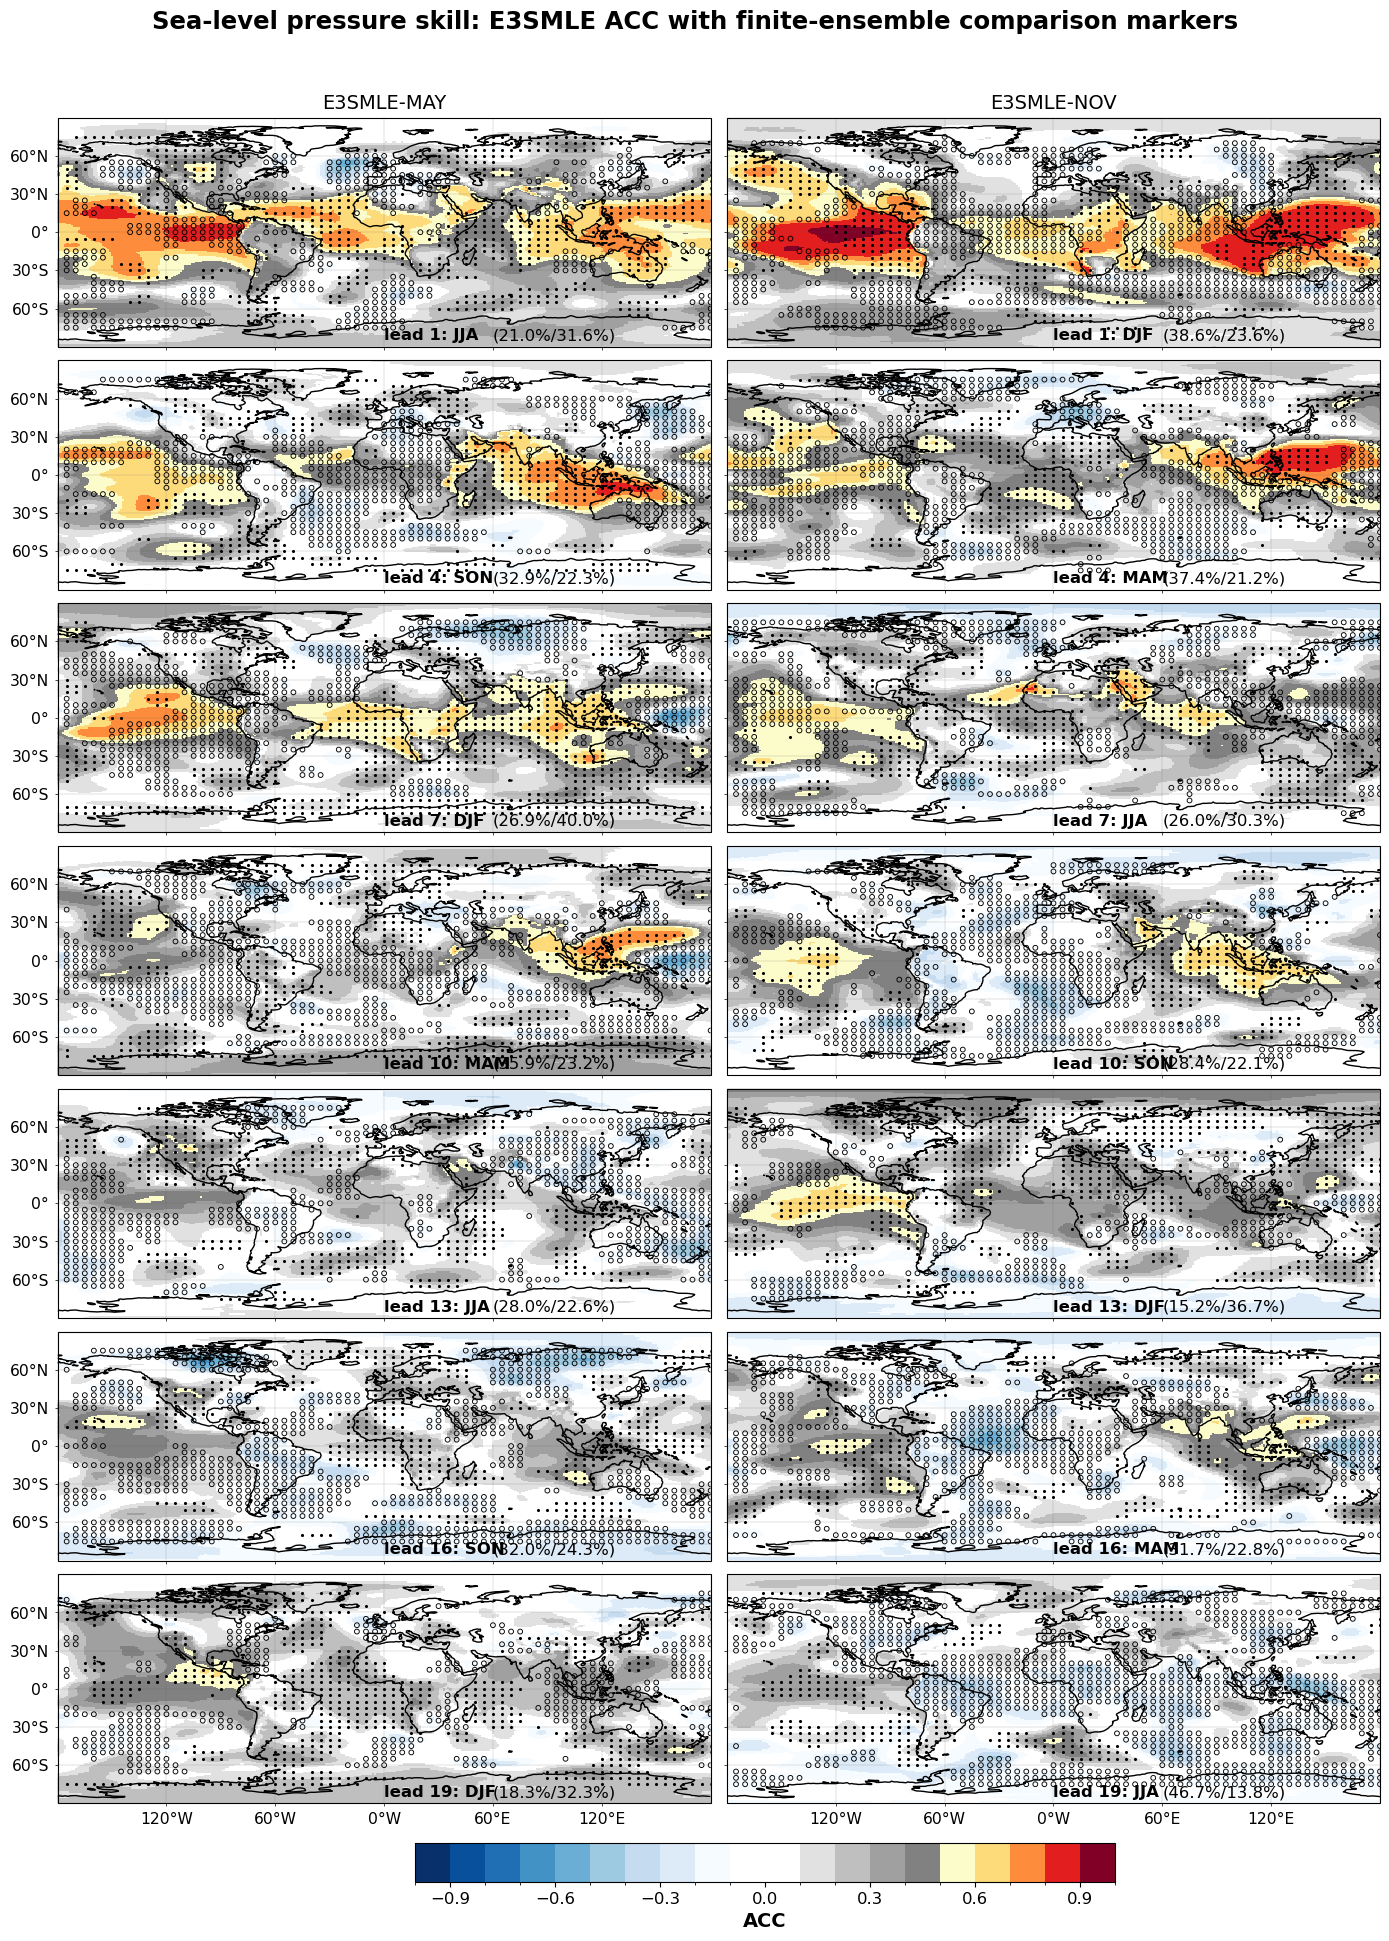

CPU times: user 13.9 s, sys: 3.84 s, total: 17.7 s
Wall time: 14 s


In [25]:
%%time
# Plot E3SMLE ACC and compare it with the ensemble-size-matched CESM-SMYLE distribution.
# Columns are initialization months: May, November.
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

ci = 0.1
cmin = -1
cmax = 1
siglvl_compare = 0.1
latlim = 80
symclr = "black"
marker_stride = 5
open_marker_size = 12
filled_marker_size = 5
marker_linewidth = 0.65

compare_fontz = 14
compare_panel_title_size = compare_fontz
compare_lead_label_size = compare_fontz * 0.85
compare_lat_lon_label_size = compare_fontz * 0.8
compare_suptitle_size = compare_fontz * 1.25
compare_colorbar_label_size = compare_fontz
compare_colorbar_tick_size = compare_fontz * 0.85
compare_fweight = "bold"

compare_init_months_plot = [m for m in [5, 11] if m in smyle_compare_skill_by_month]
plot_nlead = min(7, *(smyle_compare_skill_by_month[m].sizes["L"] for m in compare_init_months_plot))
nrows = plot_nlead
ncols = len(compare_init_months_plot)
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7 * ncols, 2.8 * nrows))
cntr = None

area = destgrid.area
valid_area = xr.where(abs(destgrid.lat) < latlim, area, 0)
valid_area_sum = valid_area.sum()

for i in range(plot_nlead):
    for j, compare_init_month in enumerate(compare_init_months_plot):
        smyle_skill = smyle_compare_skill_by_month[compare_init_month]
        e3sm_skill = e3sm_compare_skill_by_month[compare_init_month]
        accp = accpval_by_month[compare_init_month]
        lead = int(e3sm_skill.L.values[i])
        display_lead = lead - 2
        leadstr = f"lead {display_lead}: {seasonal_label(compare_init_month, display_lead)}"
        init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}")
        title = f"E3SMLE-{init_label}" if i == 0 else ""
        subplot = i * ncols + j + 1

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            e3sm_skill.corr.isel(L=i),
            e3sm_skill.lon,
            e3sm_skill.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap="blue2red_acc", cutoff=0.5,
            fontsize=compare_panel_title_size,
        )

        ax.set_xticks([-120, -60, 0, 60, 120], crs=ccrs.PlateCarree())
        ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
            labelsize=compare_lat_lon_label_size,
            length=2.5,
            width=0.5,
            top=False,
            right=False,
            labelbottom=(i == nrows - 1),
            labelleft=(j == 0),
        )
        ax.gridlines(
            crs=ccrs.PlateCarree(),
            linewidth=0.35,
            color="0.35",
            alpha=0.35,
            linestyle="-",
            draw_labels=False,
        )

        ax.text(0., -85, leadstr, fontsize=compare_lead_label_size, fontweight=compare_fweight)

        tmp = xr.where(~e3sm_skill.corr.isel(L=i).isnull(), accp.isel(L=i), np.nan)

        # Open circles: at least 90% of matched-size CESM-SMYLE samples exceed E3SMLE.
        bsmyle_better = tmp > (1 - siglvl_compare)
        tmparea = xr.where(bsmyle_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nbetter = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(bsmyle_better)[::marker_stride, ::marker_stride]
        display_lon = lon2d[::marker_stride, ::marker_stride]
        display_lat = lat2d[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
            display_lon[display_mask], display_lat[display_mask],
            facecolor="none", edgecolor=symclr,
            s=open_marker_size, linewidth=marker_linewidth, zorder=10,
        )

        # Filled dots: at most 10% of matched-size CESM-SMYLE samples exceed E3SMLE.
        e3sm_better = tmp < siglvl_compare
        tmparea = xr.where(e3sm_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nworse = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(e3sm_better)[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
            display_lon[display_mask], display_lat[display_mask],
            facecolor=symclr, edgecolor=symclr,
            s=filled_marker_size, linewidth=0, zorder=10,
        )

        ax.text(
            60., -85,
            f"({nbetter * 100:3.1f}%/{nworse * 100:3.1f}%)",
            fontsize=compare_lead_label_size,
        )

fig.suptitle(
    f"{cfg['plot_name']} skill: E3SMLE ACC with finite-ensemble comparison markers",
    fontsize=compare_suptitle_size,
    fontweight=compare_fweight,
    y=0.995,
)
# Reserve separate bands for the suptitle, column titles, and colorbar.
fig.tight_layout(rect=[0.0, 0.08, 1.0, 0.94])
fig.subplots_adjust(top=0.94, bottom=0.08, hspace=0.06, wspace=0.025)
cbar_ax = fig.add_axes([0.3, 0.04, 0.5, 0.02])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_label("ACC", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

compare_figname = figure_filename(field, "leadtime_acc", "e3smle", "bsmyle", "may_nov", "markers")
compare_figpath = FIGURE_OUTDIR / compare_figname
plt.savefig(compare_figpath, dpi=300, bbox_inches="tight")
print("Saved figure:", compare_figpath)
plt.show()


### E3SMLE Minus Ensemble-Matched CESM-SMYLE Skill
- Plots full-ensemble E3SMLE ACC minus the mean of the 10-member CESM-SMYLE resampled ACC distribution.
- Uses the same open/filled finite-ensemble significance markers.


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/esp-lab_diag/fig_psl_leadtime_acc_diff_e3smle_bsmyle_may_nov.png


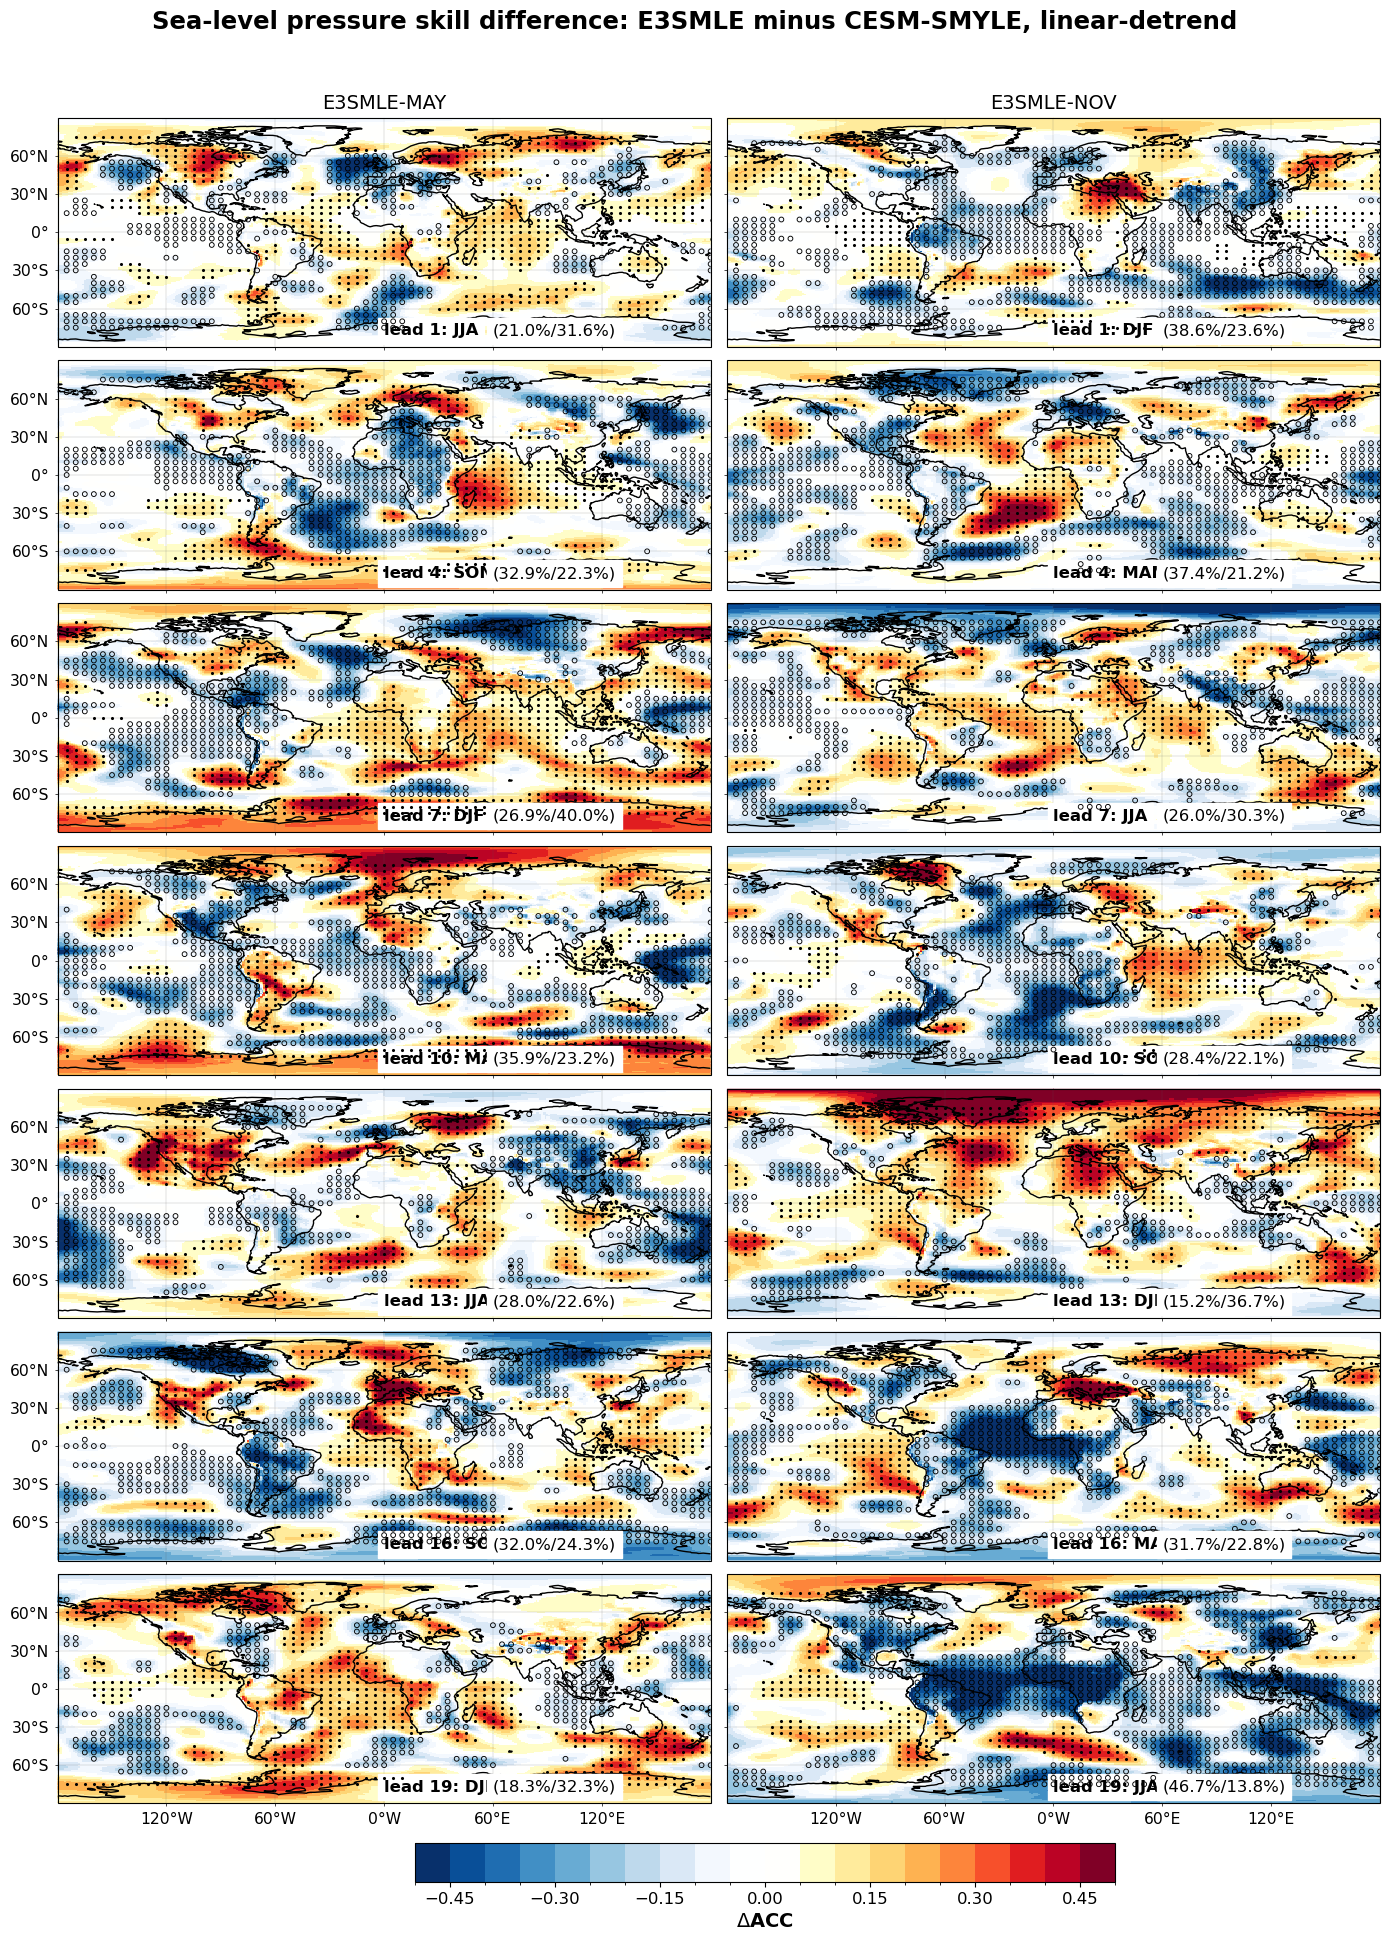

CPU times: user 15.1 s, sys: 4.01 s, total: 19.1 s
Wall time: 15.2 s


In [26]:
%%time
# Plot fixed 10-member E3SMLE ACC minus mean matched-size CESM-SMYLE ACC.
# Columns are initialization months: May, November.
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

e3sm_compare_skilldiff_by_month = {
    m: e3sm_compare_skill_by_month[m] - smyle_compare_skill_by_month[m].mean("iteration")
    for m in compare_init_months_plot
}

ci = 0.05
cmin = -0.5
cmax = 0.5
siglvl_compare = 0.1
latlim = 80
symclr = "black"
marker_stride = 5
open_marker_size = 12
filled_marker_size = 5
marker_linewidth = 0.65

compare_fontz = 14
compare_panel_title_size = compare_fontz
compare_lead_label_size = compare_fontz * 0.85
compare_lat_lon_label_size = compare_fontz * 0.8
compare_suptitle_size = compare_fontz * 1.25
compare_colorbar_label_size = compare_fontz
compare_colorbar_tick_size = compare_fontz * 0.85
compare_fweight = "bold"

plot_nlead = min(7, *(e3sm_compare_skilldiff_by_month[m].sizes["L"] for m in compare_init_months_plot))
nrows = plot_nlead
ncols = len(compare_init_months_plot)
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7 * ncols, 2.8 * nrows))
cntr = None

area = destgrid.area
valid_area = xr.where(abs(destgrid.lat) < latlim, area, 0)
valid_area_sum = valid_area.sum()

for i in range(plot_nlead):
    for j, compare_init_month in enumerate(compare_init_months_plot):
        smyle_skill = smyle_compare_skill_by_month[compare_init_month]
        skilldiff = e3sm_compare_skilldiff_by_month[compare_init_month]
        accp = accpval_by_month[compare_init_month]
        lead = int(smyle_skill.L.values[i])
        display_lead = lead - 2
        leadstr = f"lead {display_lead}: {seasonal_label(compare_init_month, display_lead)}"
        init_label = init_month_names.get(compare_init_month, f"{compare_init_month:02d}")
        title = f"E3SMLE-{init_label}" if i == 0 else ""
        subplot = i * ncols + j + 1

        ax, cntr = maps.map_pcolor_global_subplot(
            fig,
            skilldiff.corr.isel(L=i),
            smyle_skill.lon,
            smyle_skill.lat,
            ci, cmin, cmax,
            title,
            nrows, ncols, subplot,
            proj, cmap="blue2red", cutoff=0.5,
            fontsize=compare_panel_title_size,
        )

        ax.set_xticks([-120, -60, 0, 60, 120], crs=ccrs.PlateCarree())
        ax.set_yticks([-60, -30, 0, 30, 60], crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(
            labelsize=compare_lat_lon_label_size,
            length=2.5,
            width=0.5,
            top=False,
            right=False,
            labelbottom=(i == nrows - 1),
            labelleft=(j == 0),
        )
        ax.gridlines(
            crs=ccrs.PlateCarree(),
            linewidth=0.35,
            color="0.35",
            alpha=0.35,
            linestyle="-",
            draw_labels=False,
        )

        ax.text(
            0., -81, leadstr,
            fontsize=compare_lead_label_size,
            fontweight=compare_fweight,
            backgroundcolor="white",
            zorder=10,
        )

        tmp = xr.where(~skilldiff.corr.isel(L=i).isnull(), accp.isel(L=i), np.nan)

        # Open circles: at least 90% of matched-size CESM-SMYLE samples exceed E3SMLE.
        bsmyle_better = tmp > (1 - siglvl_compare)
        tmparea = xr.where(bsmyle_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nbetter = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(bsmyle_better)[::marker_stride, ::marker_stride]
        display_lon = lon2d[::marker_stride, ::marker_stride]
        display_lat = lat2d[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
            display_lon[display_mask], display_lat[display_mask],
            facecolor="none", edgecolor=symclr,
            s=open_marker_size, linewidth=marker_linewidth, zorder=10,
        )

        # Filled dots: at most 10% of matched-size CESM-SMYLE samples exceed E3SMLE.
        e3sm_better = tmp < siglvl_compare
        tmparea = xr.where(e3sm_better, area, 0)
        tmparea = xr.where(abs(destgrid.lat) < latlim, tmparea, 0)
        nworse = float(tmparea.sum() / valid_area_sum)
        display_mask = np.asarray(e3sm_better)[::marker_stride, ::marker_stride]
        display_mask &= abs(display_lat) < latlim
        ax.scatter(
            display_lon[display_mask], display_lat[display_mask],
            facecolor=symclr, edgecolor=symclr,
            s=filled_marker_size, linewidth=0, zorder=10,
        )

        ax.text(
            60., -81,
            f"({nbetter * 100:3.1f}%/{nworse * 100:3.1f}%)",
            fontsize=compare_lead_label_size,
            backgroundcolor="white",
            zorder=10,
        )

fig.suptitle(
    f"{cfg['plot_name']} skill difference: E3SMLE minus CESM-SMYLE, linear-detrend",
    fontsize=compare_suptitle_size,
    fontweight=compare_fweight,
    y=0.995,
)
# Reserve separate bands for the suptitle, column titles, and colorbar.
fig.tight_layout(rect=[0.0, 0.08, 1.0, 0.94])
fig.subplots_adjust(top=0.94, bottom=0.08, hspace=0.06, wspace=0.025)
cbar_ax = fig.add_axes([0.3, 0.04, 0.5, 0.02])
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation="horizontal")
cbar.set_label(r"${\Delta}$ACC", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

skilldiff_figname = figure_filename(field, "leadtime_acc_diff", "e3smle", "bsmyle", "may_nov")
skilldiff_figpath = FIGURE_OUTDIR / skilldiff_figname
plt.savefig(skilldiff_figpath, dpi=300, bbox_inches="tight")
print("Saved figure:", skilldiff_figpath)
plt.show()
